# Introducing Optimization

This notebook will cover optimization techniques for training neural networks, including:
- Gradient descent
- Backpropagation
- Optimizers (SGD, Adam, etc.)
- Learning rate scheduling
- Regularization techniques



Now that the neural network is built, able to have data passed through it, and capable of 
calculating loss, the next step is to determine how to adjust the weights and biases to decrease the 
loss. Finding an intelligent way to adjust the neurons’ input’s weights and biases to minimize loss 
is the main difficulty of neural networks.

The first option one might think of is randomly changing the weights, checking the loss, and 
repeating this until happy with the lowest loss found. To see this in action, we’ll use a simpler 
dataset than we’ve been working with so far:

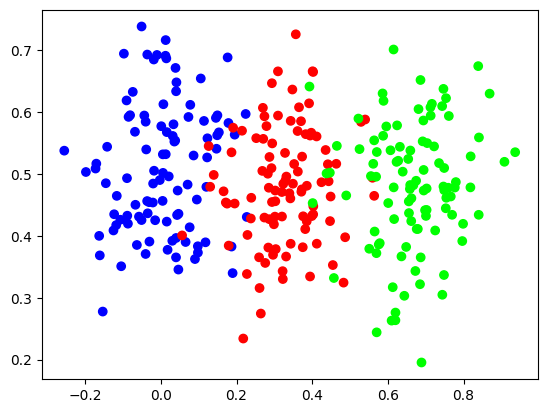

In [2]:
import matplotlib.pyplot as plt
from nnfs.datasets import vertical_data
import nnfs

nnfs.init()

X, y = vertical_data(samples=100, classes=3)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="brg")
plt.show()

Using the previously created code up to this point, we can use this new dataset with a simple 
neural network:

In [3]:
import numpy as np
import nnfs
from nnfs.datasets import spiral_data

nnfs.init()

# Dense layer
class Layer_Dense:
    # Layer initialization
    def __init__(self, n_inputs, n_neurons):
        # Initialize weights and biases
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

    # Forward pass
    def forward(self, inputs):
        # Calculate output values from inputs, weights and biases
        self.output = np.dot(inputs, self.weights) + self.biases

# ReLU activation
class Activation_ReLU:
    # Forward pass
    def forward(self, inputs):
        # Calculate output values from inputs
        self.output = np.maximum(0, inputs)

# Softmax activation
class Activation_Softmax:
    # Forward pass
    def forward(self, inputs):
        # Get unnormalized probabilities
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        # Normalize them for each sample
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True)
        self.output = probabilities

# Common loss class
class Loss:
    # Calculates the data and regularization losses
    # given model output and ground truth values
    def calculate(self, output, y):
        # Calculate sample losses
        sample_losses = self.forward(output, y)
        # Calculate mean loss
        data_loss = np.mean(sample_losses)
        # Return loss
        return data_loss

# Cross-entropy loss
class Loss_CategoricalCrossentropy(Loss):
    # Forward pass
    def forward(self, y_pred, y_true):
        # Number of samples in a batch
        samples = len(y_pred)
        # Clip data to prevent division by 0
        # Clip both sides to not drag mean towards any value
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)

        # Probabilities for target values -
        # only if categorical labels
        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[
                range(samples), y_true
            ]
        # Mask values - only for one-hot encoded labels
        elif len(y_true.shape) == 2:
            correct_confidences = np.sum(
                y_pred_clipped * y_true, axis=1
            )

        # Losses
        negative_log_likelihoods = -np.log(correct_confidences)
        return negative_log_likelihoods

# Create dataset
X, y = spiral_data(samples=100, classes=3)

# Create Dense layer with 2 input features and 3 output values
dense1 = Layer_Dense(2, 3)

# Create ReLU activation (to be used with Dense layer)
activation1 = Activation_ReLU()

# Create second Dense layer with 3 input features (as we take output
# of previous layer here) and 3 output values
dense2 = Layer_Dense(3, 3)

# Create Softmax activation (to be used with Dense layer)
activation2 = Activation_Softmax()

# Create loss function
loss_function = Loss_CategoricalCrossentropy()

# Perform a forward pass of our training data through this layer
dense1.forward(X)

# Perform a forward pass through activation function
# it takes the output of first dense layer here
activation1.forward(dense1.output)

# Perform a forward pass through second Dense layer
# it takes outputs of activation function of first layer as inputs
dense2.forward(activation1.output)

# Perform a forward pass through activation function
# it takes the output of second dense layer here
activation2.forward(dense2.output)

# Let's see output of the first few samples
print("First 5 softmax outputs:")
print(activation2.output[:5])

# Perform a forward pass through loss function
# it takes the output of second dense layer here and returns loss
loss = loss_function.calculate(activation2.output, y)

# Print loss value
print(f'Loss: {loss}')

First 5 softmax outputs:
[[0.33333334 0.33333334 0.33333334]
 [0.3333332  0.3333332  0.33333364]
 [0.3333329  0.33333293 0.3333342 ]
 [0.3333326  0.33333263 0.33333477]
 [0.33333233 0.3333324  0.33333528]]
Loss: 1.0986104011535645


In [4]:
X, y = vertical_data(samples=100, classes=3)

dense1 = Layer_Dense(2,3)
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3,3)
activation2 = Activation_Softmax()

loss_function = Loss_CategoricalCrossentropy()


In [5]:
lowest_loss = 9999999
best_dense_weights = dense1.weights.copy()
best_dense_biases = dense1.biases.copy()
best_dense2_weights = dense2.weights.copy()
best_dense2_biases = dense2.biases.copy()


We initialized the loss to a large value and will decrease it when a new, lower, loss is found. We 
are also copying weights and biases (​copy()​ ensures a full copy instead of a reference to the 
object). Now we iterate as many times as desired, pick random values for weights and biases, and 
save the weights and biases if they generate the lowest-seen loss:

In [8]:
for iteration in range(10000):
    # generate a new set of weights for iteration

    dense1.weights = 0.05 * np.random.randn(2,3)
    dense1.biases = 0.05 * np.random.rand(1,3)
    dense2.weights = 0.05 * np.random.randn(3,3)
    dense2.biases = 0.05 * np.random.randn(1,3)

    # perform a forward pass of training data thorugh this layer
    dense1.forward(X)
    activation1.forward(dense1.output)
    dense2.forward(dense1.output)
    activation2.forward(dense2.output) 

    # Perform a forward pass through the activation function 
    # it takes the output of the second dense layer here and returns loss
    loss = loss_function.calculate(activation2.output, y)

    # calculate accuracy from output of activation2 and targets
    # calculate values along first axis
    predictions = np.argmax(activation2.output, axis=1)
    accuracy = np.mean(predictions==y)

    # if loss is smaller - print and save weights and bises aside
    if loss < lowest_loss:
        print("New set of weights found, iteration:", iteration, "Loss: ", loss, "acc :", accuracy)

        best_dense1_weights = dense1.weights.copy()
        best_dense1_biases = dense1.biases.copy()
        best_dense2_weights = dense2.weights.copy()
        best_dense2_biases = dense2.biases.copy()
        lowest_loss = loss 

    # revert weights and biases
    else:
        dense1.weights = best_dense1_biases.copy()
        dense1.biases = best_dense1_biases.copy()
        dense2.weights = best_dense2_weights.copy()
        dense2.biases = best_dense2_biases.copy()
        

New set of weights found, iteration: 3801 Loss:  1.0954484 acc : 0.3333333333333333


In [ ]:
# And that's for the optimizers !